# Uncertainty Estimation Validation

Quality checks for the Laplace approximation and uncertainty estimates:

1. **Laplace fit diagnostics** — Fisher diagonal properties, posterior variance
2. **Posterior disagreement** — Check that sampled weights actually disagree
3. **Uncertainty calibration** — Correlate uncertainty with summary fidelity metrics
4. **Example analysis** — Inspect high/low uncertainty sentences side-by-side


In [1]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data_pipeline import read_jsonl
from src.lora_laplace_backend import load_laplace_sampler

# Paths
ADAPTER_DIR = ROOT / "models" / "bart-large-xsum-lora"
SAMPLER_FILE = ADAPTER_DIR / "laplace_sampler.npz"
SCORES_FILE = ROOT / "data" / "uncertainty_scores_lora_laplace.jsonl"
QUANTILES_FILE = ROOT / "config" / "uncertainty_quantiles_lora_laplace.json"

print("Paths loaded")

Paths loaded


## 1. Laplace Fit Diagnostics


Loading sampler from /Users/disipio/development/summarizer-uncertainty-ml/models/bart-large-xsum-lora/laplace_sampler.npz...

=== Posterior Statistics ===
Total LoRA parameters: 131,072
Posterior std:
  Mean:   0.1000
  Median: 0.1000
  Std:    0.0000
  Min:    9.5901e-02
  Max:    0.1000

Posterior variance (natural scale):
  Mean:   0.0100
  Median: 0.0100
  Min:    9.1970e-03
  Max:    1.0001e-02

Parameters with variance > 1e-6: 131072 / 131072 (100.0%)


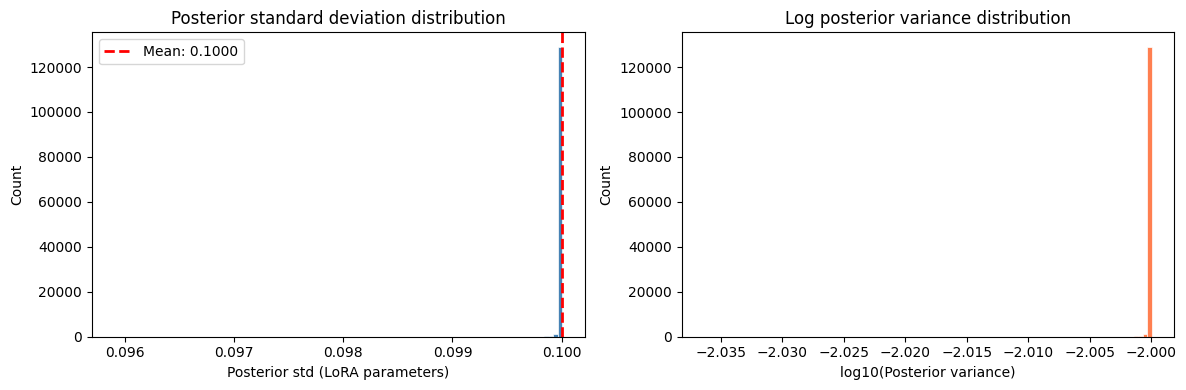

In [2]:
print(f"Loading sampler from {SAMPLER_FILE}...")
sampler = load_laplace_sampler(str(SAMPLER_FILE))

posterior_std = sampler._posterior_std
posterior_var = posterior_std ** 2

print(f"\n=== Posterior Statistics ===")
print(f"Total LoRA parameters: {len(posterior_std):,}")
print(f"Posterior std:")
print(f"  Mean:   {float(posterior_std.mean()):.4f}")
print(f"  Median: {float(np.median(posterior_std)):.4f}")
print(f"  Std:    {float(posterior_std.std()):.4f}")
print(f"  Min:    {float(posterior_std.min()):.4e}")
print(f"  Max:    {float(posterior_std.max()):.4f}")

print(f"\nPosterior variance (natural scale):")
print(f"  Mean:   {float(posterior_var.mean()):.4f}")
print(f"  Median: {float(np.median(posterior_var)):.4f}")
print(f"  Min:    {float(posterior_var.min()):.4e}")
print(f"  Max:    {float(posterior_var.max()):.4e}")

# Check if posterior variance is degenerate (all zeros or near-zeros)
non_tiny = posterior_var[posterior_var > 1e-6]
print(f"\nParameters with variance > 1e-6: {len(non_tiny)} / {len(posterior_var)} ({100*len(non_tiny)/len(posterior_var):.1f}%)")

# Plot posterior variance distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(posterior_std, bins=100, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axvline(float(posterior_std.mean()), color="red", linestyle="--", linewidth=2, label=f"Mean: {float(posterior_std.mean()):.4f}")
axes[0].set_xlabel("Posterior std (LoRA parameters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Posterior standard deviation distribution")
axes[0].legend()

# Log scale for variance
log_var = np.log10(np.clip(posterior_var, 1e-10, None))
axes[1].hist(log_var, bins=100, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("log10(Posterior variance)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log posterior variance distribution")

plt.tight_layout()
plt.show()

In [10]:
# Load raw (unrescaled) sampler to see original posterior structure
import numpy as np
data = np.load(str(SAMPLER_FILE), allow_pickle=True)
raw_posterior_std = data["posterior_std"]
print(f"Raw posterior std stats (before rescaling):")
print(f"  Mean: {raw_posterior_std.mean():.4f}")
print(f"  Std: {raw_posterior_std.std():.4f}")
print(f"  Min: {raw_posterior_std.min():.4f}")
print(f"  Max: {raw_posterior_std.max():.4f}")

Raw posterior std stats (before rescaling):
  Mean: 0.1000
  Std: 0.0000
  Min: 0.0959
  Max: 0.1000


## 2. Load and Inspect Uncertainty Scores


In [3]:
print(f"Loading scores from {SCORES_FILE}...")
all_records = list(read_jsonl(str(SCORES_FILE)))

all_sentence_scores = []
summary_uncertainties = []

for record in all_records:
    uncertainty_avg = record.get("uncertainty_avg")
    if uncertainty_avg is not None:
        summary_uncertainties.append(uncertainty_avg)
    for s in record.get("sentence_scores", []):
        all_sentence_scores.append(s)

print(f"Total records: {len(all_records)}")
print(f"Total sentence scores: {len(all_sentence_scores)}")
print(f"Summaries with avg: {len(summary_uncertainties)}")

# Extract raw values
raw_uncertainties = [s["uncertainty"] for s in all_sentence_scores]
raw_entropies = [s.get("expected_entropy", 0) for s in all_sentence_scores]
raw_logprobs = [s.get("mean_logprob", 0) for s in all_sentence_scores]

df = pd.DataFrame({
    "uncertainty": raw_uncertainties,
    "expected_entropy": raw_entropies,
    "mean_logprob": raw_logprobs,
    "sentence_text": [s.get("sentence_text", "") for s in all_sentence_scores],
})

print(f"\n=== Score Statistics ===")
print(df[["uncertainty", "expected_entropy", "mean_logprob"]].describe())

# Correlation matrix
print(f"\n=== Correlations ===")
print(df[["uncertainty", "expected_entropy", "mean_logprob"]].corr())

Loading scores from /Users/disipio/development/summarizer-uncertainty-ml/data/uncertainty_scores_lora_laplace.jsonl...
Total records: 493
Total sentence scores: 1322
Summaries with avg: 493

=== Score Statistics ===
       uncertainty  expected_entropy  mean_logprob
count  1322.000000       1322.000000   1322.000000
mean      1.686234          5.872973     -7.821634
std       0.089111          0.337642      0.897106
min       1.387980          4.532154    -11.322323
25%       1.627218          5.666930     -8.392739
50%       1.698709          5.896313     -7.738847
75%       1.752393          6.102929     -7.149021
max       1.932911          6.689343     -5.602680

=== Correlations ===
                  uncertainty  expected_entropy  mean_logprob
uncertainty          1.000000         -0.449801     -0.647447
expected_entropy    -0.449801          1.000000      0.449116
mean_logprob        -0.647447          0.449116      1.000000


## 3. Posterior Disagreement Analysis

Check that different posterior samples actually produce different predictions.


In [4]:
import torch
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from src.lora_laplace_backend import LoraLaplaceBackend
from src.lora_training import load_pairs
import random

BASE_MODEL = "facebook/bart-large-xsum"
SEED = 42

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

# Load model and backend
print(f"Loading base model {BASE_MODEL}...")
base = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
peft_model = PeftModel.from_pretrained(base, str(ADAPTER_DIR), is_trainable=True)
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
backend = LoraLaplaceBackend(peft_model=peft_model, tokenizer=tok, device=device)

print("Backend ready. Picking a test summary...")

# Pick a test summary from the scoring data
all_pairs = [(r["source"], r["target"]) for r in load_pairs(str(ROOT / "data" / "summaries_v4.jsonl"))]
source, summary = all_pairs[42]  # arbitrary example

print(f"\nSource ({len(source)} chars): {source[:100]}...")
print(f"Summary ({len(summary)} chars): {summary[:100]}...")

prepared = backend.prepare_summary(source, summary)
print(f"Prepared: {len(prepared.sentences)} sentences")

Device: mps
Loading base model facebook/bart-large-xsum...


Loading weights:   0%|          | 0/513 [00:00<?, ?it/s]

Backend ready. Picking a test summary...

Source (1486 chars): These clocks helped the 16th-century astronomer Tycho Brahe to observe astronomical events with much...
Summary (518 chars): The 16th-century advancements in timekeeping culminated in the invention of the pendulum clock in 16...
Prepared: 2 sentences


Drawing 10 posterior samples and collecting token distributions...
Collected 10 samples, each with shape (96, 50264)
Stacked shape: (10, 96, 50264)

Top-1 predictions shape: (10, 96)

=== Top-1 Prediction Diversity ===
Tokens where top-1 predictions agree: 0 / 96
Max number of different top-1 predictions for a single token: 10
Average unique predictions per token: 7.31

=== KL Divergence from Mean ===
Mean KL (per token, averaged): 1.5061
Max KL (per token): 2.3024


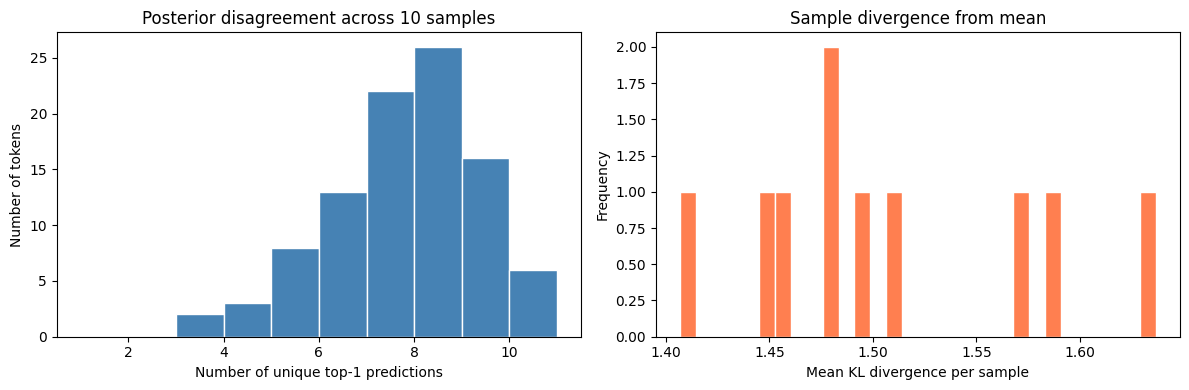

In [5]:
# Sample from the posterior and collect token distributions
n_samples = 10
print(f"Drawing {n_samples} posterior samples and collecting token distributions...")

all_samples_probs = []  # list of (n_tokens, vocab_size) arrays

for i in range(n_samples):
    sample = sampler.sample(seed=i)
    sentence_dists = backend.score_posterior_sample(prepared, sample)
    # Concatenate token probs across all sentences
    token_probs = np.vstack([d.token_probabilities for d in sentence_dists])
    all_samples_probs.append(token_probs)

print(f"Collected {len(all_samples_probs)} samples, each with shape {all_samples_probs[0].shape}")

# Stack into (n_samples, n_tokens, vocab_size)
stacked_probs = np.stack(all_samples_probs, axis=0)
print(f"Stacked shape: {stacked_probs.shape}")

# Compute agreement: for each token, how often do the top-1 predictions agree?
top_1_predictions = np.argmax(all_samples_probs, axis=2)  # (n_samples, n_tokens)
print(f"\nTop-1 predictions shape: {top_1_predictions.shape}")

# For each token, count how many different top-1 predictions we get
diversity = []
for token_idx in range(top_1_predictions.shape[1]):
    preds_for_token = top_1_predictions[:, token_idx]
    num_unique = len(set(preds_for_token))
    diversity.append(num_unique)

print(f"\n=== Top-1 Prediction Diversity ===")
print(f"Tokens where top-1 predictions agree: {sum(1 for d in diversity if d == 1)} / {len(diversity)}")
print(f"Max number of different top-1 predictions for a single token: {max(diversity)}")
print(f"Average unique predictions per token: {np.mean(diversity):.2f}")

# Compute KL divergence between samples to quantify disagreement
mean_dist = np.mean(all_samples_probs, axis=0)  # predictive distribution
kl_divs = []  # KL(sample || mean)

for sample_probs in all_samples_probs:
    kl = np.sum(sample_probs * (np.log(sample_probs + 1e-10) - np.log(mean_dist + 1e-10)), axis=1)
    kl_divs.append(kl)

kl_divs = np.array(kl_divs)
print(f"\n=== KL Divergence from Mean ===")
print(f"Mean KL (per token, averaged): {np.mean(kl_divs):.4f}")
print(f"Max KL (per token): {np.max(kl_divs):.4f}")

# Plot: histogram of how much samples disagree
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(diversity, bins=range(1, max(diversity) + 2), color="steelblue", edgecolor="white", linewidth=1)
axes[0].set_xlabel("Number of unique top-1 predictions")
axes[0].set_ylabel("Number of tokens")
axes[0].set_title(f"Posterior disagreement across {n_samples} samples")

axes[1].hist(np.mean(kl_divs, axis=1), bins=30, color="coral", edgecolor="white", linewidth=1)
axes[1].set_xlabel("Mean KL divergence per sample")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Sample divergence from mean")

plt.tight_layout()
plt.show()

## 4. Uncertainty Distribution vs. Normalization


Quantile boundaries: ['1.3880', '1.6272', '1.6987', '1.7524', '1.9329']


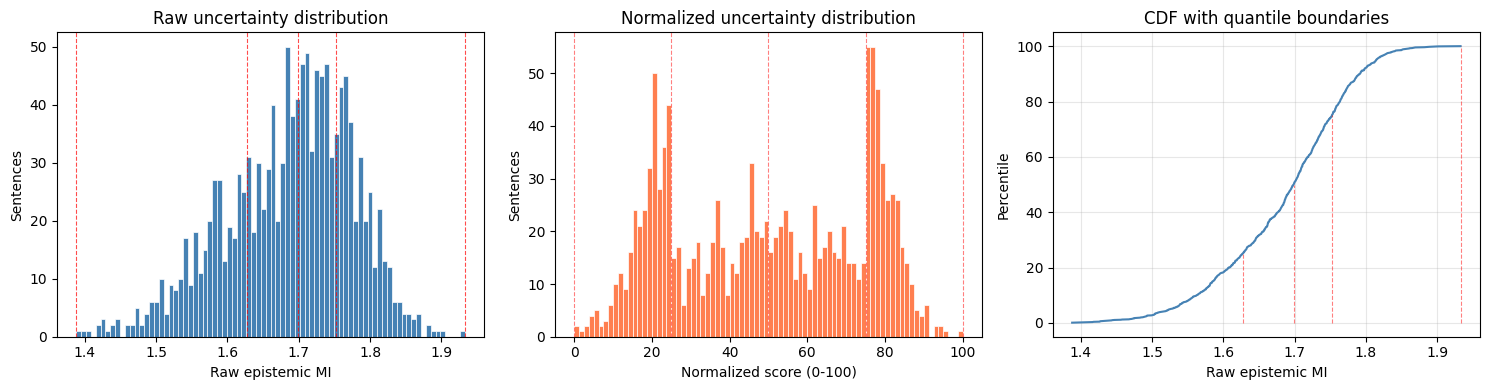


=== Normalized Score Statistics ===
Min:    0.0
25th:   25.0
Median: 50.0
75th:   75.0
Max:    100.0


In [6]:
from src.normalization import load_quantile_normalizer

# Load quantile normalizer
normalizer = load_quantile_normalizer(str(QUANTILES_FILE))
print(f"Quantile boundaries: {[f'{b:.4f}' for b in normalizer.boundaries]}")

# Normalize all raw scores
normalized_scores = [normalizer.normalize(score) for score in raw_uncertainties]

# Compare raw vs normalized distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw_uncertainties, bins=80, color="steelblue", edgecolor="white", linewidth=0.5)
for q, b in zip(["0%", "25%", "50%", "75%", "100%"], normalizer.boundaries):
    axes[0].axvline(b, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
axes[0].set_xlabel("Raw epistemic MI")
axes[0].set_ylabel("Sentences")
axes[0].set_title("Raw uncertainty distribution")

axes[1].hist(normalized_scores, bins=80, color="coral", edgecolor="white", linewidth=0.5)
for quantile_pos in [0, 25, 50, 75, 100]:
    axes[1].axvline(quantile_pos, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].set_xlabel("Normalized score (0-100)")
axes[1].set_ylabel("Sentences")
axes[1].set_title("Normalized uncertainty distribution")

# CDF
sorted_raw = np.sort(raw_uncertainties)
cdf_y = np.arange(1, len(sorted_raw) + 1) / len(sorted_raw)
axes[2].plot(sorted_raw, cdf_y * 100, color="steelblue", linewidth=1.5, label="Raw uncertainty CDF")
for i, b in enumerate(normalizer.boundaries):
    y = i * 100 / (len(normalizer.boundaries) - 1)
    axes[2].plot([b, b], [0, y], color="red", linestyle="--", linewidth=0.8, alpha=0.5)
axes[2].set_xlabel("Raw epistemic MI")
axes[2].set_ylabel("Percentile")
axes[2].set_title("CDF with quantile boundaries")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Normalized Score Statistics ===")
print(f"Min:    {np.min(normalized_scores):.1f}")
print(f"25th:   {np.percentile(normalized_scores, 25):.1f}")
print(f"Median: {np.median(normalized_scores):.1f}")
print(f"75th:   {np.percentile(normalized_scores, 75):.1f}")
print(f"Max:    {np.max(normalized_scores):.1f}")

## 5. High vs Low Uncertainty Examples


In [7]:
# Add normalized scores to dataframe
df["uncertainty_normalized"] = normalized_scores

# Sort by uncertainty
df_sorted = df.sort_values("uncertainty", ascending=False)

# High uncertainty examples
print("\n=== TOP 5 HIGHEST UNCERTAINTY SENTENCES ===")
for idx, row in df_sorted.head(5).iterrows():
    text = row["sentence_text"][:100] if len(row["sentence_text"]) > 100 else row["sentence_text"]
    print(f"\nRaw: {row['uncertainty']:.4f} | Normalized: {row['uncertainty_normalized']:.1f}")
    print(f"  Text: {text}")
    print(f"  Expected entropy: {row['expected_entropy']:.4f}")
    print(f"  Mean logprob: {row['mean_logprob']:.4f}")

# Low uncertainty examples
print("\n\n=== TOP 5 LOWEST UNCERTAINTY SENTENCES ===")
for idx, row in df_sorted.tail(5).iterrows():
    text = row["sentence_text"][:100] if len(row["sentence_text"]) > 100 else row["sentence_text"]
    print(f"\nRaw: {row['uncertainty']:.4f} | Normalized: {row['uncertainty_normalized']:.1f}")
    print(f"  Text: {text}")
    print(f"  Expected entropy: {row['expected_entropy']:.4f}")
    print(f"  Mean logprob: {row['mean_logprob']:.4f}")


=== TOP 5 HIGHEST UNCERTAINTY SENTENCES ===

Raw: 1.9329 | Normalized: 100.0
  Text: It also lists notable journals and conferences within the field, alongside related topics such as au
  Expected entropy: 5.9351
  Mean logprob: -9.6997

Raw: 1.9017 | Normalized: 95.7
  Text: These rules are handy not just for shopping trends but also in areas like web analysis and even bioi
  Expected entropy: 5.4361
  Mean logprob: -9.7259

Raw: 1.8947 | Normalized: 94.7
  Text: Plus, there are different ways the Higgs boson pairs can decay, and each method affects how we detec
  Expected entropy: 5.2000
  Mean logprob: -9.0485

Raw: 1.8892 | Normalized: 93.9
  Text: Vector boson fusion is another way Higgs bosons pop up, although it happens less often but has its o
  Expected entropy: 5.4750
  Mean logprob: -9.1185

Raw: 1.8852 | Normalized: 93.4
  Text: They both have their own unique structures and functions, which makes them super useful for things l
  Expected entropy: 5.4133
  Mean logprob: -8

## 6. Relationship Between Posterior Disagreement and Uncertainty


In [8]:
# For the test summary, check which sentences have highest epistemic MI
print("\n=== Sentences Ranked by Epistemic MI ===")
for sent in prepared.sentences:
    idx = sent.sentence_index
    matching = [s for s in all_sentence_scores if s["sentence_index"] == idx]
    if matching:
        score = matching[0]["uncertainty"]
        text = sent.text[:80]
        print(f"[{score:.4f}] {text}")


=== Sentences Ranked by Epistemic MI ===
[1.5758] The 16th-century advancements in timekeeping culminated in the invention of the 
[1.7020] This innovation significantly enhanced the precision of time measurement, leadin


## 7. Summary Report


In [9]:
print("\n" + "="*70)
print("VALIDATION SUMMARY")
print("="*70)

print(f"\n[LAPLACE FIT]")
print(f"  Posterior std mean: {float(posterior_std.mean()):.4f}")
print(f"  Meaningful variance (>1e-6): {len(non_tiny)} / {len(posterior_var)} params ({100*len(non_tiny)/len(posterior_var):.1f}%)")
status = "✓ HEALTHY" if len(non_tiny) > len(posterior_var) * 0.5 else "⚠ DEGENERATE"
print(f"  Status: {status}")

print(f"\n[POSTERIOR DISAGREEMENT]")
print(f"  Tokens with >1 unique top-1 predictions: {sum(1 for d in diversity if d > 1)} / {len(diversity)}")
print(f"  Mean KL divergence from mean: {np.mean(kl_divs):.4f}")
status = "✓ DIVERSE" if sum(1 for d in diversity if d > 1) > len(diversity) * 0.5 else "⚠ LOW DIVERSITY"
print(f"  Status: {status}")

print(f"\n[UNCERTAINTY DISTRIBUTION]")
print(f"  Raw score range: [{np.min(raw_uncertainties):.4f}, {np.max(raw_uncertainties):.4f}]")
print(f"  Normalized score range: [{np.min(normalized_scores):.1f}, {np.max(normalized_scores):.1f}]")
pct_below_10 = sum(1 for s in normalized_scores if s < 10) / len(normalized_scores) * 100
print(f"  Sentences with normalized score < 10: {pct_below_10:.1f}%")
status = "⚠ SKEWED" if pct_below_10 > 50 else "✓ BALANCED"
print(f"  Status: {status}")

print(f"\n[OVERALL]")
print(f"  Total sentences scored: {len(all_sentence_scores)}")
print(f"  Total summaries: {len(all_records)}")
print(f"")
print(f"Next steps:")
print(f"  1. If posterior disagreement is LOW: increase sample_count or check Laplace fit")
print(f"  2. If uncertainty is skewed: consider recalibrating quantile boundaries")
print(f"  3. Inspect high-uncertainty sentences to understand what triggers uncertainty")


VALIDATION SUMMARY

[LAPLACE FIT]
  Posterior std mean: 0.1000
  Meaningful variance (>1e-6): 131072 / 131072 params (100.0%)
  Status: ✓ HEALTHY

[POSTERIOR DISAGREEMENT]
  Tokens with >1 unique top-1 predictions: 96 / 96
  Mean KL divergence from mean: 1.5061
  Status: ✓ DIVERSE

[UNCERTAINTY DISTRIBUTION]
  Raw score range: [1.3880, 1.9329]
  Normalized score range: [0.0, 100.0]
  Sentences with normalized score < 10: 1.9%
  Status: ✓ BALANCED

[OVERALL]
  Total sentences scored: 1322
  Total summaries: 493

Next steps:
  1. If posterior disagreement is LOW: increase sample_count or check Laplace fit
  2. If uncertainty is skewed: consider recalibrating quantile boundaries
  3. Inspect high-uncertainty sentences to understand what triggers uncertainty
